In [92]:
import numpy as np
np.set_printoptions(threshold=np.inf)
import matplotlib.pyplot as plt
from scipy.io import loadmat
import random
import seaborn as sns
from math import sqrt
sns.set_theme()

[[ 1.82 15.56]
 [ 2.95 16.11]
 [ 3.11 14.89]
 [ 2.01 15.98]
 [ 3.56 15.23]
 [ 1.45 14.76]
 [ 3.98 16.02]
 [ 2.67 15.11]
 [14.12 15.34]
 [15.67 14.89]
 [16.21 15.76]
 [14.89 16.23]
 [15.34 15.11]
 [16.78 14.67]
 [ 2.11  4.34]
 [ 3.56  3.89]
 [ 2.89  5.12]
 [ 3.98  4.67]
 [ 1.67  3.98]
 [ 4.12  3.23]
 [15.34  3.89]
 [14.89  4.67]
 [16.21  3.12]
 [15.67  5.01]
 [14.23  3.67]
 [ 2.34 15.67]
 [ 3.12 16.23]
 [15.78 15.34]
 [16.12 14.98]
 [ 3.45  4.12]
 [ 2.67  3.89]
 [15.23  4.34]
 [14.67  3.98]
 [ 1.98 14.98]
 [ 3.67 15.34]
 [14.56 16.01]
 [16.34 15.45]
 [ 2.56  4.76]
 [ 3.78  3.56]
 [15.89  4.23]
 [14.45  5.12]
 [ 2.89 15.45]
 [ 3.23 14.76]
 [15.12 15.67]
 [16.45 16.12]
 [ 3.12  4.34]
 [ 2.45  5.01]
 [15.45  3.78]
 [14.78  4.56]]


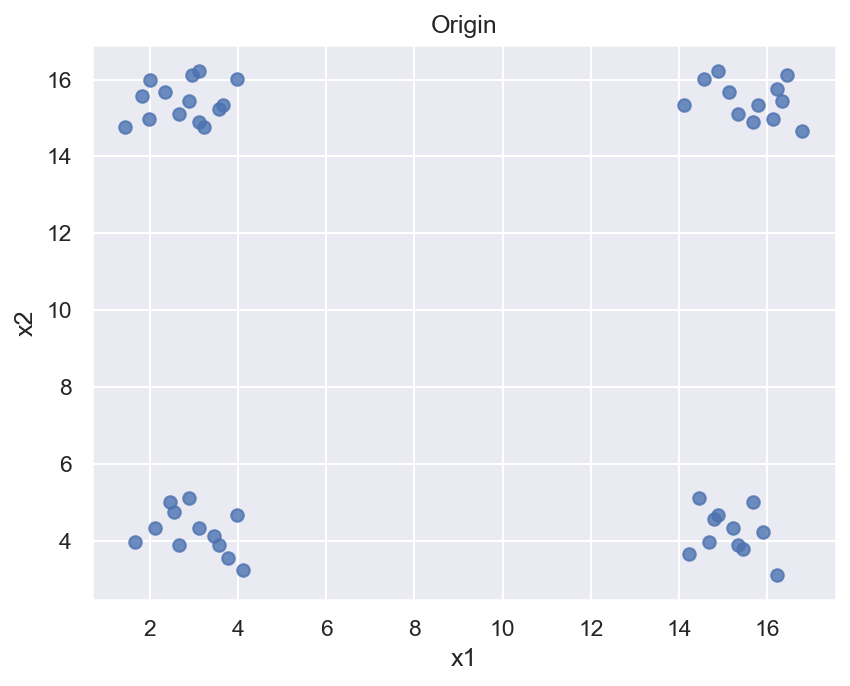

In [93]:
data = loadmat('cluster_dataset.mat')
X = data['data']
np.set_printoptions(precision=3, suppress=True)
print(X)
x1 = np.array([i[0] for i in X])
x2 = np.array([i[1] for i in X])
plt.figure(dpi=150)
plt.scatter(x1,x2,color='b',alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Origin')
plt.show()

In [94]:
#预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
k = 4

In [95]:
#随机选择数据集中k个点作为初始聚类中心
def init_centers(X,k):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int)
    输出：centers：初始化的中心集（建议：元素为ndarray的list)
    可能使用的函数：random.randint
    注意：需保证随机取的样本不重复
    """
    n=X.shape[0]
    index=random.sample(range(n),k)
    centers=[X[i] for i in index]
    return centers

In [96]:
#向量欧氏距离计算，用于计算每个样本和中心的距离，可用于簇分配和代价函数计算
def distance(v1, v2):
    """
    输入：v1:样本(ndarray), v2:当前对应的中心(ndarray)
    输出：distance:欧氏距离(float/ndarray)
    """
    distance=sqrt((v1[0]-v2[0])*(v1[0]-v2[0])+(v1[1]-v2[1])*(v1[1]-v2[1]))
    return distance

In [97]:
#将样本分配到距离最近的中心所在的簇
def cluster_assignment(X, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心集（建议：元素为ndarray的list)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list)
    可能使用的函数：np.argmin
    注意：list和array在某些计算时的转换
    """
    assignment={}
    len1=len(X)
    len2=len(centers)
    for i in range(len2):
        assignment[i]=[]
    for i in range(len1):
        dis=999999999
        num=0
        for j in range(len2):
            d=distance(X[i],centers[j])
            if d <= dis :
                num=j
                dis=d
        assignment[num].append(X[i])
    return assignment

In [98]:
#代价函数：所有数据点到当前对应中心的欧氏距离之和的平均值
def cost_function(assignment, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心（建议：元素为ndarray的list)
    输出：cost:代价函数值（float/ndarray）
    可能使用的函数：np.argmin
    注意：list和array在使用np函数计算时的转换
    """
    sum=0
    count=0
    for i in assignment:
        for j in assignment[i]:
            sum+=distance(centers[i],j)
            count+=1
    if count == 0:
        return 0
    cost=sum/count
    return cost

In [99]:
#更新中心,满足停机条件（聚类中心不再改变）时结束更新
def center_update(assignment, centers):
    """
    输入：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), centers：当前中心（建议：元素为ndarray的list)
    输出：new_centers:更新的中心集（建议：元素为ndarray的list), stop：停机条件标识（不停机：0/停机：1）
    可能使用的函数：np.mean
    注意：list和array在使用np函数计算时的转换
    """
    new_centers=[]
    stop=1
    for i in assignment:#字典循环的i是key，列表循环的i就是里面的数据类型
        sumx=0
        sumy=0
        num=0
        for j in assignment[i]:
            sumx+=j[0]
            sumy+=j[1]
            num+=1
        if num != 0:
            sumx/=num
            sumy/=num
        if abs(sumx-centers[i][0])>0.000001 or abs(sumy-centers[i][1])>0.000001:
            stop=0    
        new_centers.append(np.array([sumx,sumy]))
    return new_centers, stop

In [100]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    color = ['r', 'b', 'c', 'g', 'k', 'w', 'y', 'm']
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:,0]
        x2 = cluster[:,1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker = '*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch'+ str(epoch))
    plt.show()

In [101]:
#kmeans及可视化
def kmeans(X, k, max_epoch, plot=True):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int), max_epoch：最大训练轮数(int), plot:是否可视化（True/False)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), cost:最终的代价函数值，用于k-cost曲线的绘制（float/ndarray）
    """
    centers=init_centers(X,k)
    stop=0
    new_centers=[]
    for i in range(max_epoch):
        assignment=cluster_assignment(X,centers)
        new_centers,stop=center_update(assignment,centers)
        if stop == 1:
            break
        centers=new_centers
    cost=cost_function(assignment,centers)
    return assignment, cost, centers

In [102]:
max_epoch = 200 

In [103]:
assignment, _, _ = kmeans(X, k, max_epoch)

In [104]:
def plot_original_points_with_centers(X, centers):
    plt.figure(dpi=150)
    # 画原始数据点（蓝色）
    plt.scatter(X[:, 0], X[:, 1], color='blue', alpha=0.8, label='数据点')
    
    # 画中心点（红色，兼容列表类型的 centers）
    for c in centers:
        plt.scatter(c[0], c[1], color='red', s=150, marker='*', edgecolors='black', label='中心点')
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('K-Means 结果（红点=中心点）')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

k=1中心点：
[8.762,10.182] 




<Figure size 960x720 with 0 Axes>

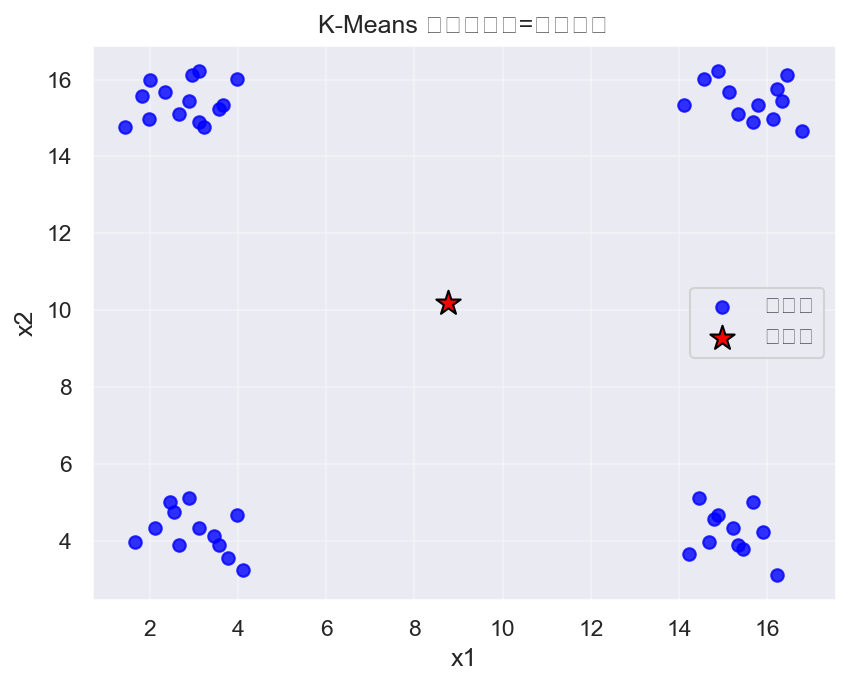

k=2中心点：
[15.400,10.084] 
[2.890,10.269] 




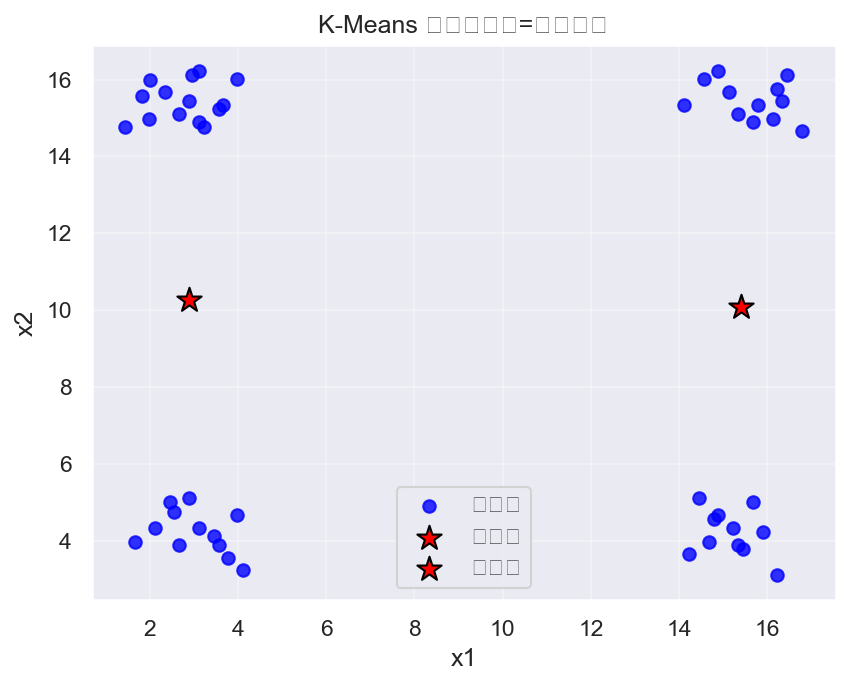

k=3中心点：
[8.833,4.230] 
[2.770,15.435] 
[15.615,15.464] 




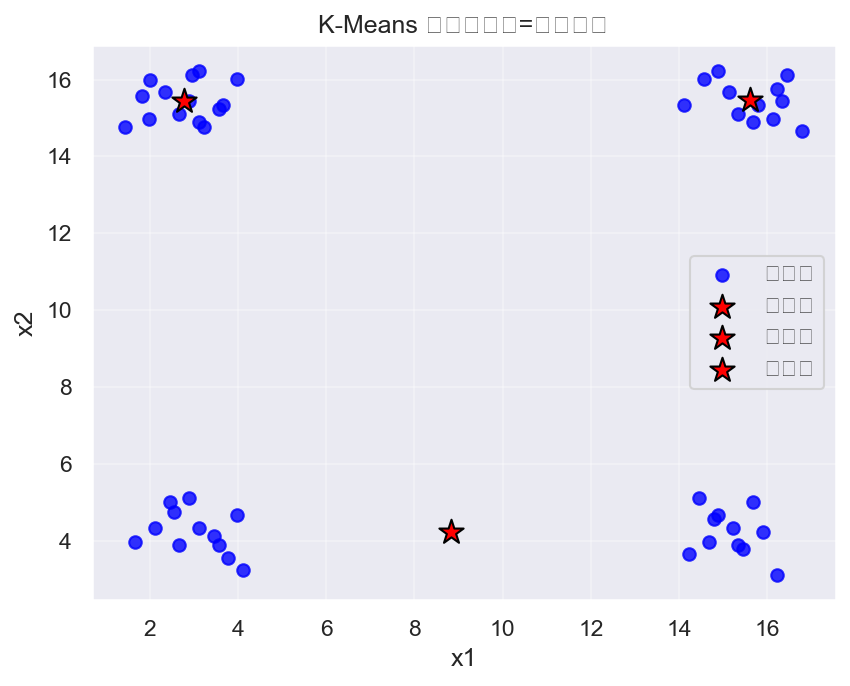

k=4中心点：
[15.165,4.215] 
[15.615,15.464] 
[3.030,4.243] 
[2.770,15.435] 




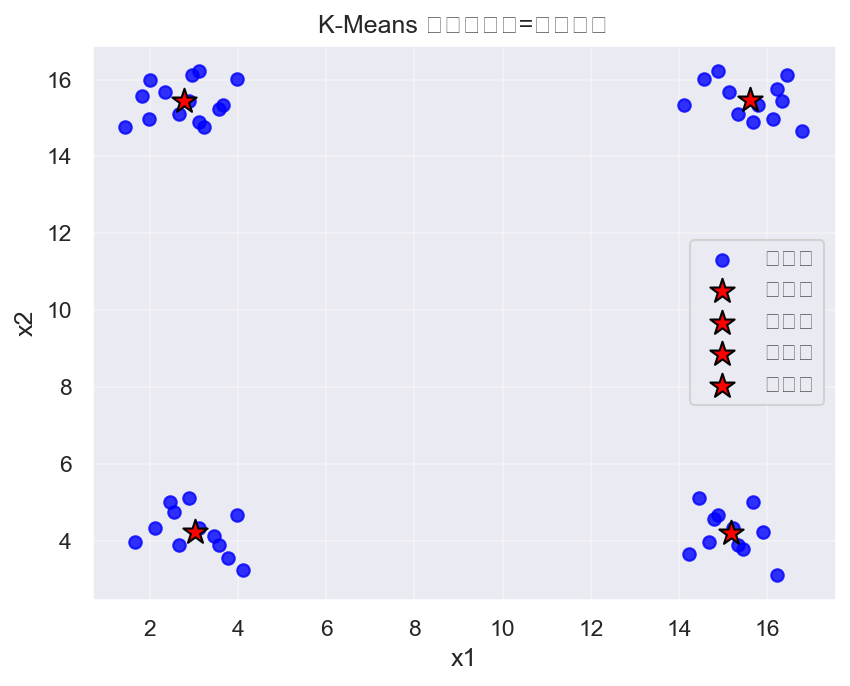

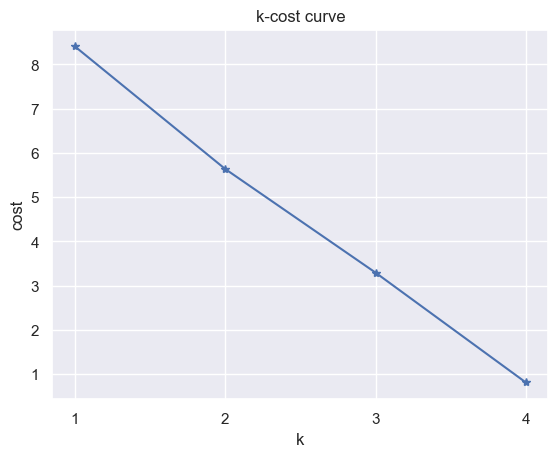

In [105]:
#绘制簇数-代价函数曲线：根据曲线，观察最合适的簇数k的选择
np.set_printoptions(threshold=np.inf)  
plt.figure(dpi=150)
Cost = []
max_k = 5
centers=[]
for k in range(1, max_k):
    _, cost, centers = kmeans(X, k, max_epoch,False)
    Cost.append(cost)
    print(f"k={k}中心点：")
    for i in centers:
        print(f"[{i[0]:.3f},{i[1]:.3f}] ")
    print("\n")
    plot_original_points_with_centers(X,centers)
plt.plot(range(1,max_k), Cost, c='b', marker = '*')
plt.xticks(range(1,max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()